🔥 CELL 1 — Install Dependencies


In [ ]:
!pip install -q kaggle scikit-learn seaborn


CELL 2 — Upload Kaggle API Key

In [ ]:
from google.colab import files
files.upload()   # Upload kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"maheshyemineni","key":"KGAT_1735b45dae8c824f3544b2f83c635564"}\r\n'}

CELL 3 — Configure Kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


🔥 CELL 4 — Download Dataset Directly

In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -oq new-plant-diseases-dataset.zip



Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.69G/2.70G [00:26<00:00, 248MB/s]
100% 2.70G/2.70G [00:26<00:00, 108MB/s]


🔥 CELL 5 — Imports

In [ ]:
import tensorflow as tf
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


🔥 CELL 6 — Enable Mixed Precision (Faster Training)

In [ ]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')


🔥 CELL 7 — Dataset Path & Parameters

In [ ]:
DATA_DIR = "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15



🔥 CELL 8 — Load Dataset


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Total Classes:", NUM_CLASSES)

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


Found 70295 files belonging to 38 classes.
Using 56236 files for training.
Found 70295 files belonging to 38 classes.
Using 14059 files for validation.
Total Classes: 38


🔥 CELL 9 — Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])


🔥 CELL 10 — Build EfficientNetV2B0 Model

In [ ]:
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = tf.keras.Model(inputs, outputs)


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step



🔥 CELL 11 — Compile Model


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")
    ]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,262,134 (23.89 MB)

 Trainable params: 340,262 (1.30 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

🔥 CELL 12 — Callbacks

In [ ]:
callbacks = [
    EarlyStopping(patience=4, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=2),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]


🔥 CELL 13 — Train Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7350 - loss: 0.9319 - top3_acc: 0.8790

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 163s 85ms/step - accuracy: 0.7351 - loss: 0.9317 - top3_acc: 0.8790 - val_accuracy: 0.9358 - val_loss: 0.1928 - val_top3_acc: 0.9934 - learning_rate: 0.0010
Epoch 2/15
1757/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8996 - loss: 0.3218 - top3_acc: 0.9825

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 133s 76ms/step - accuracy: 0.8996 - loss: 0.3218 - top3_acc: 0.9825 - val_accuracy: 0.9576 - val_loss: 0.1249 - val_top3_acc: 0.9965 - learning_rate: 0.0010
Epoch 3/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 132s 75ms/step - accuracy: 0.9128 - loss: 0.2711 - top3_acc: 0.9869 - val_accuracy: 0.9580 - val_loss: 0.1256 - val_top3_acc: 0.9971 - learning_rate: 0.0010
Epoch 4/15
1757/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9200 - loss: 0.2526 - top3_acc: 0.9882

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 153s 87ms/step - accuracy: 0.9200 - loss: 0.2526 - top3_acc: 0.9882 - val_accuracy: 0.9599 - val_loss: 0.1150 - val_top3_acc: 0.9969 - learning_rate: 0.0010
Epoch 5/15
1757/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9272 - loss: 0.2268 - top3_acc: 0.9904

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 133s 75ms/step - accuracy: 0.9272 - loss: 0.2268 - top3_acc: 0.9904 - val_accuracy: 0.9686 - val_loss: 0.0946 - val_top3_acc: 0.9974 - learning_rate: 0.0010
Epoch 6/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 141s 75ms/step - accuracy: 0.9302 - loss: 0.2283 - top3_acc: 0.9898 - val_accuracy: 0.9649 - val_loss: 0.1046 - val_top3_acc: 0.9979 - learning_rate: 0.0010
Epoch 7/15
1757/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9297 - loss: 0.2196 - top3_acc: 0.9914

...

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 142s 76ms/step - accuracy: 0.9460 - loss: 0.1677 - top3_acc: 0.9935 - val_accuracy: 0.9770 - val_loss: 0.0670 - val_top3_acc: 0.9986 - learning_rate: 3.0000e-04
Epoch 11/15
1757/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9520 - loss: 0.1458 - top3_acc: 0.9950

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 132s 75ms/step - accuracy: 0.9520 - loss: 0.1458 - top3_acc: 0.9950 - val_accuracy: 0.9784 - val_loss: 0.0625 - val_top3_acc: 0.9987 - learning_rate: 3.0000e-04
Epoch 12/15
1757/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9559 - loss: 0.1299 - top3_acc: 0.9958

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 132s 75ms/step - accuracy: 0.9559 - loss: 0.1299 - top3_acc: 0.9958 - val_accuracy: 0.9797 - val_loss: 0.0602 - val_top3_acc: 0.9991 - learning_rate: 3.0000e-04
Epoch 13/15
1757/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9584 - loss: 0.1250 - top3_acc: 0.9968

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 142s 75ms/step - accuracy: 0.9584 - loss: 0.1250 - top3_acc: 0.9968 - val_accuracy: 0.9793 - val_loss: 0.0583 - val_top3_acc: 0.9992 - learning_rate: 3.0000e-04
Epoch 14/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 133s 76ms/step - accuracy: 0.9606 - loss: 0.1172 - top3_acc: 0.9965 - val_accuracy: 0.9781 - val_loss: 0.0626 - val_top3_acc: 0.9991 - learning_rate: 3.0000e-04
Epoch 15/15
1757/1758 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9587 - loss: 0.1252 - top3_acc: 0.9959

1758/1758 ━━━━━━━━━━━━━━━━━━━━ 143s 77ms/step - accuracy: 0.9587 - loss: 0.1252 - top3_acc: 0.9959 - val_accuracy: 0.9797 - val_loss: 0.0581 - val_top3_acc: 0.9993 - learning_rate: 3.0000e-04


🔥 CELL 14 — Fine-Tuning

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(train_ds, validation_data=val_ds, epochs=5)


Epoch 1/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 182s 91ms/step - accuracy: 0.9304 - loss: 0.2145 - val_accuracy: 0.9768 - val_loss: 0.0696
Epoch 2/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 150s 85ms/step - accuracy: 0.9472 - loss: 0.1620 - val_accuracy: 0.9803 - val_loss: 0.0631
Epoch 3/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 201s 85ms/step - accuracy: 0.9525 - loss: 0.1466 - val_accuracy: 0.9804 - val_loss: 0.0596
Epoch 4/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 151s 86ms/step - accuracy: 0.9554 - loss: 0.1359 - val_accuracy: 0.9820 - val_loss: 0.0573
Epoch 5/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 150s 85ms/step - accuracy: 0.9606 - loss: 0.1241 - val_accuracy: 0.9835 - val_loss: 0.0504


🔥 CELL 15 — Save Final Model (.h5)

In [ ]:
model.save("plant_disease_model_final.h5")


🔥 CELL 16 — Download Model & Classes

In [ ]:
from google.colab import files
files.download("plant_disease_model_final.h5")
files.download("class_names.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🔥 CELL 17 — Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━

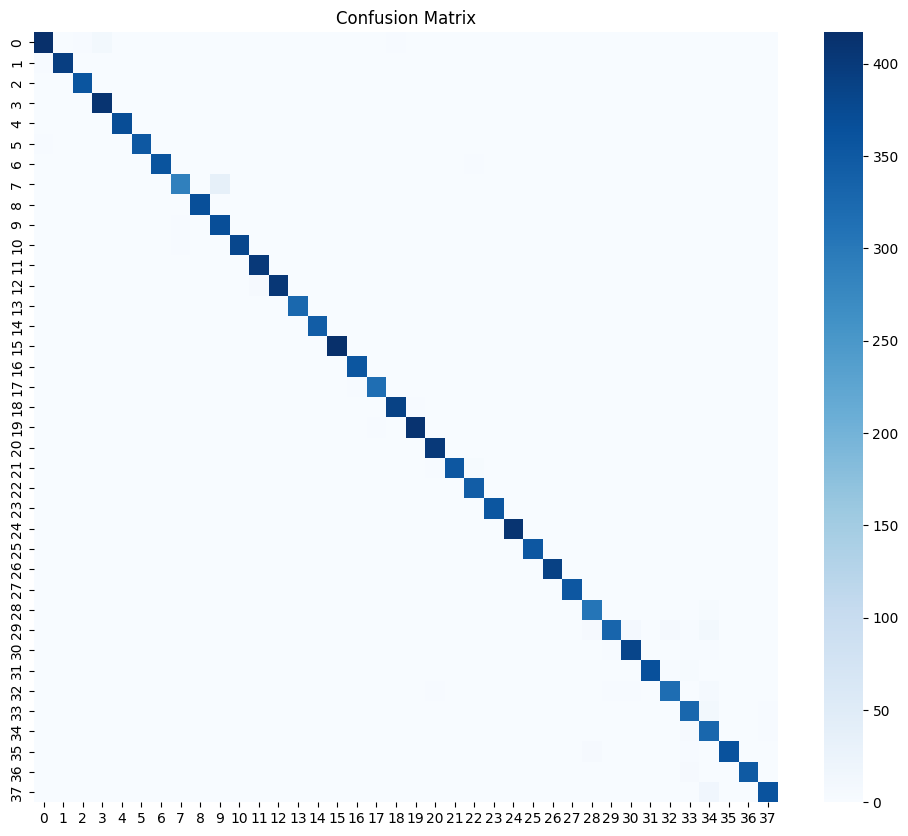

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.97      0.98       431
                                 Apple___Black_rot       1.00      0.99      0.99       397
                          Apple___Cedar_apple_rust       0.99      0.99      0.99       360
                                   Apple___healthy       0.97      1.00      0.98       411
                               Blueberry___healthy       0.99      1.00      0.99       371
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       355
                 Cherry_(including_sour)___healthy       1.00      0.99      1.00       361
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.89      0.93       325
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       367
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.99      0.

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


🔥 CELL 18 — Accuracy & Loss Graphs

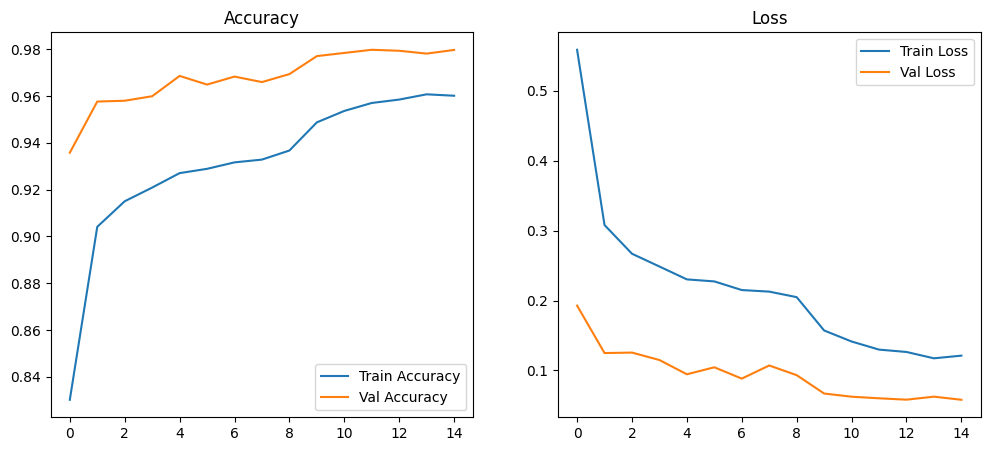

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()
